In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Configurazione stile
plt.style.use('dark_background')
sns.set_palette("husl")
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)

# ============================================================================
# CELLA 1: Caricamento dati
# ============================================================================

base_path = Path('../datasets/processed-handwritten')
datasets = {
    'IAM': base_path / 'iam_processed',
    'RIMES': base_path / 'rimes_processed'
}

# Raccolta informazioni
data = []
for name, path in datasets.items():
    for author_dir in path.iterdir():
        if author_dir.is_dir():
            num_images = len(list(author_dir.glob('*.png')))
            if num_images > 0:
                data.append({'dataset': name, 'author': author_dir.name, 'num_images': num_images})

df = pd.DataFrame(data)
print(df.head(10))
print(f"\nShape: {df.shape}")

  dataset author  num_images
0     IAM    257           1
1     IAM    111           4
2     IAM    272           3
3     IAM    340           9
4     IAM    227           1
5     IAM    259           2
6     IAM    508           1
7     IAM    517           1
8     IAM    524           1
9     IAM    009           2

Shape: (2157, 3)


In [9]:
# ============================================================================
# CELLA 2: Statistiche generali
# ============================================================================

summary = df.groupby('dataset').agg({
    'author': 'count',
    'num_images': ['sum', 'mean', 'median', 'std', 'min', 'max']
}).round(2)

summary.columns = ['Autori', 'Tot Immagini', 'Media/Autore', 'Mediana/Autore', 
                   'Std/Autore', 'Min/Autore', 'Max/Autore']

print("\n" + "="*80)
print("STATISTICHE DATASET")
print("="*80)
print(summary)


STATISTICHE DATASET
         Autori  Tot Immagini  Media/Autore  Mediana/Autore  Std/Autore  \
dataset                                                                   
IAM         657          1539          2.34             1.0        3.03   
RIMES      1500          5046          3.36             3.0        1.27   

         Min/Autore  Max/Autore  
dataset                          
IAM               1          59  
RIMES             1          10  


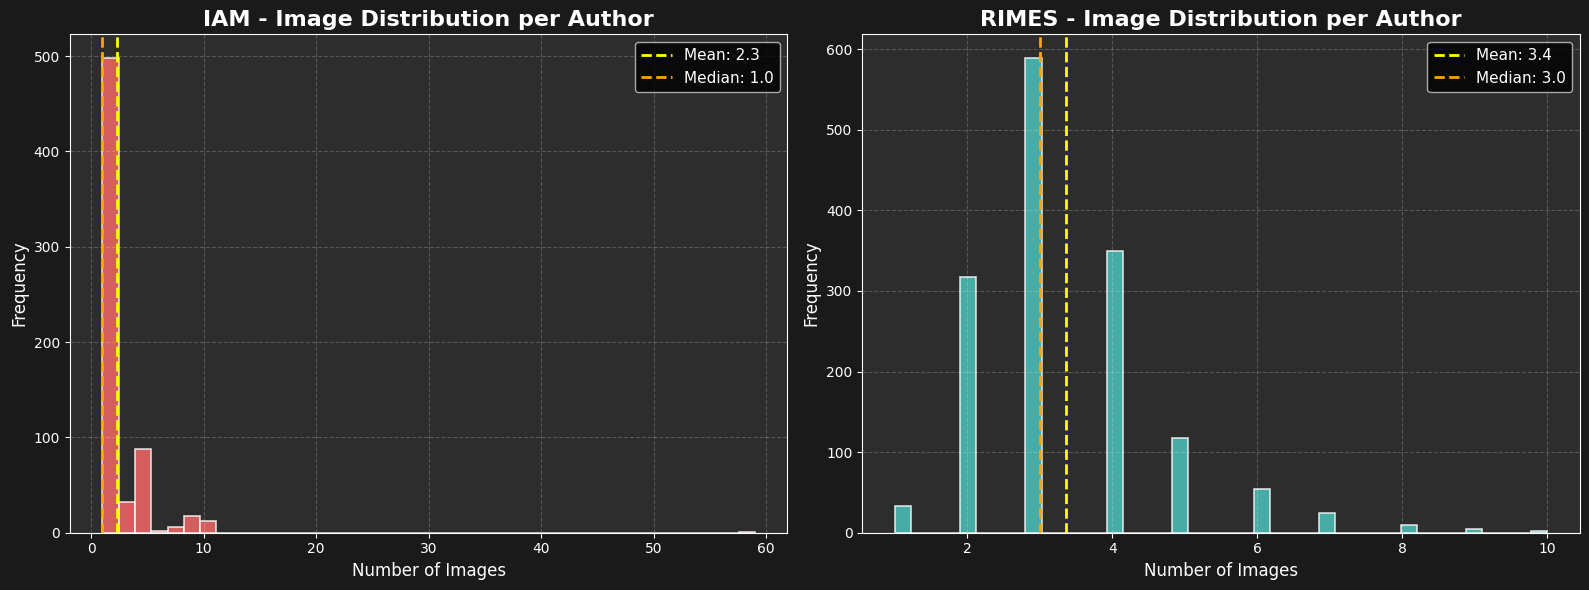

In [10]:
# ============================================================================
# CELL 3: Visualization of image distribution per author
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a1a')

for idx, (name, color) in enumerate(zip(['IAM', 'RIMES'], colors)):
    subset = df[df['dataset'] == name]['num_images']
    
    axes[idx].hist(subset, bins=40, color=color, edgecolor='white', 
                   linewidth=1.2, alpha=0.8)
    axes[idx].axvline(subset.mean(), color='yellow', linestyle='--', 
                      linewidth=2, label=f'Mean: {subset.mean():.1f}')
    axes[idx].axvline(subset.median(), color='orange', linestyle='--', 
                      linewidth=2, label=f'Median: {subset.median():.1f}')
    
    axes[idx].set_title(f'{name} - Image Distribution per Author', 
                       fontsize=16, fontweight='bold', color='white')
    axes[idx].set_xlabel('Number of Images', fontsize=12, color='white')
    axes[idx].set_ylabel('Frequency', fontsize=12, color='white')
    axes[idx].legend(fontsize=11)
    axes[idx].grid(True, alpha=0.2, linestyle='--')
    axes[idx].set_facecolor('#2d2d2d')

plt.tight_layout()
plt.savefig(IMG_DIR + '/distribution_images.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

[0      1
1      4
2      3
3      9
4      1
      ..
652    1
653    1
654    1
655    2
656    1
Name: num_images, Length: 657, dtype: int64, 657     4
658     1
659     3
660     5
661     3
       ..
2152    2
2153    2
2154    3
2155    4
2156    6
Name: num_images, Length: 1500, dtype: int64]


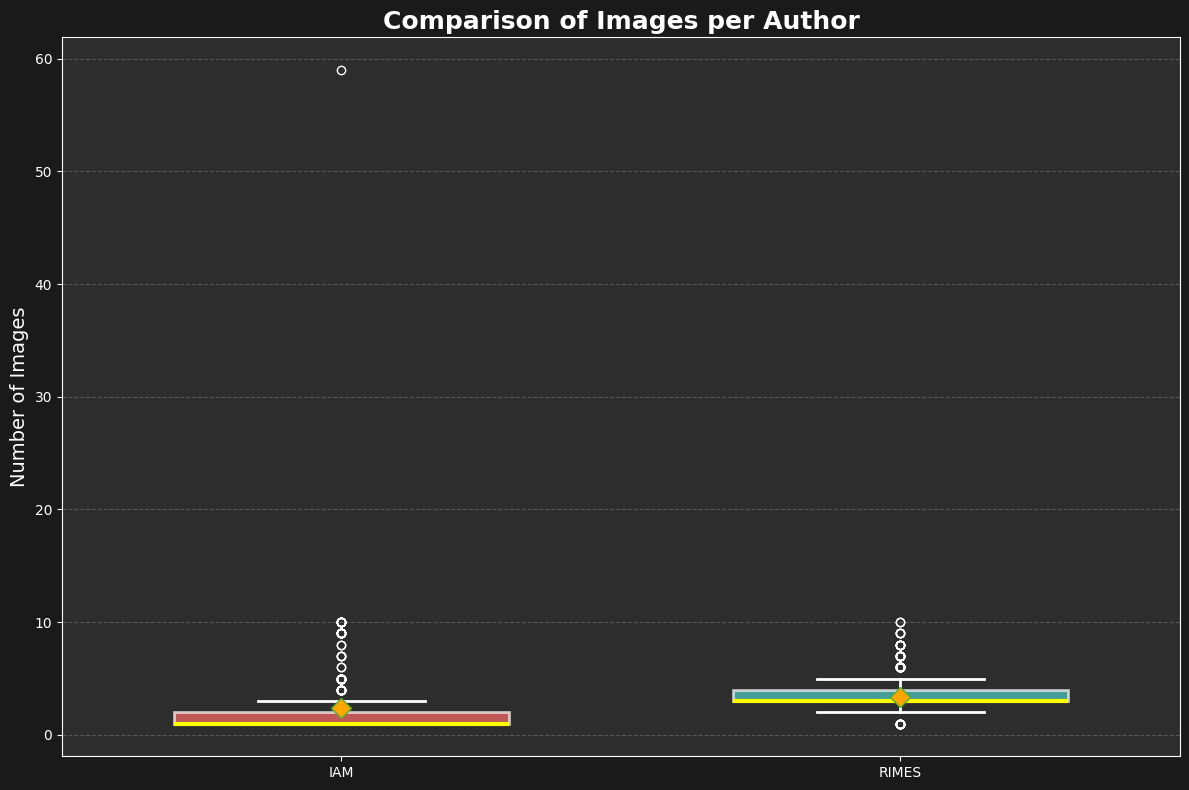

In [11]:
# ============================================================================
# CELL 4: Comparative box plot
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a1a')

box_data = [df[df['dataset'] == name]['num_images'] for name in ['IAM', 'RIMES']]
print(box_data)

bp = ax.boxplot(box_data, tick_labels=['IAM', 'RIMES'], patch_artist=True,
                widths=0.6, showmeans=True,
                boxprops=dict(linewidth=2),
                whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2),
                medianprops=dict(linewidth=3, color='yellow'),
                meanprops=dict(marker='D', markerfacecolor='orange', markersize=10))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Comparison of Images per Author', fontsize=18, fontweight='bold', color='white')
ax.set_ylabel('Number of Images', fontsize=14, color='white')
ax.set_facecolor('#2d2d2d')
ax.grid(True, alpha=0.2, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig(IMG_DIR + '/boxplot_comparison.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

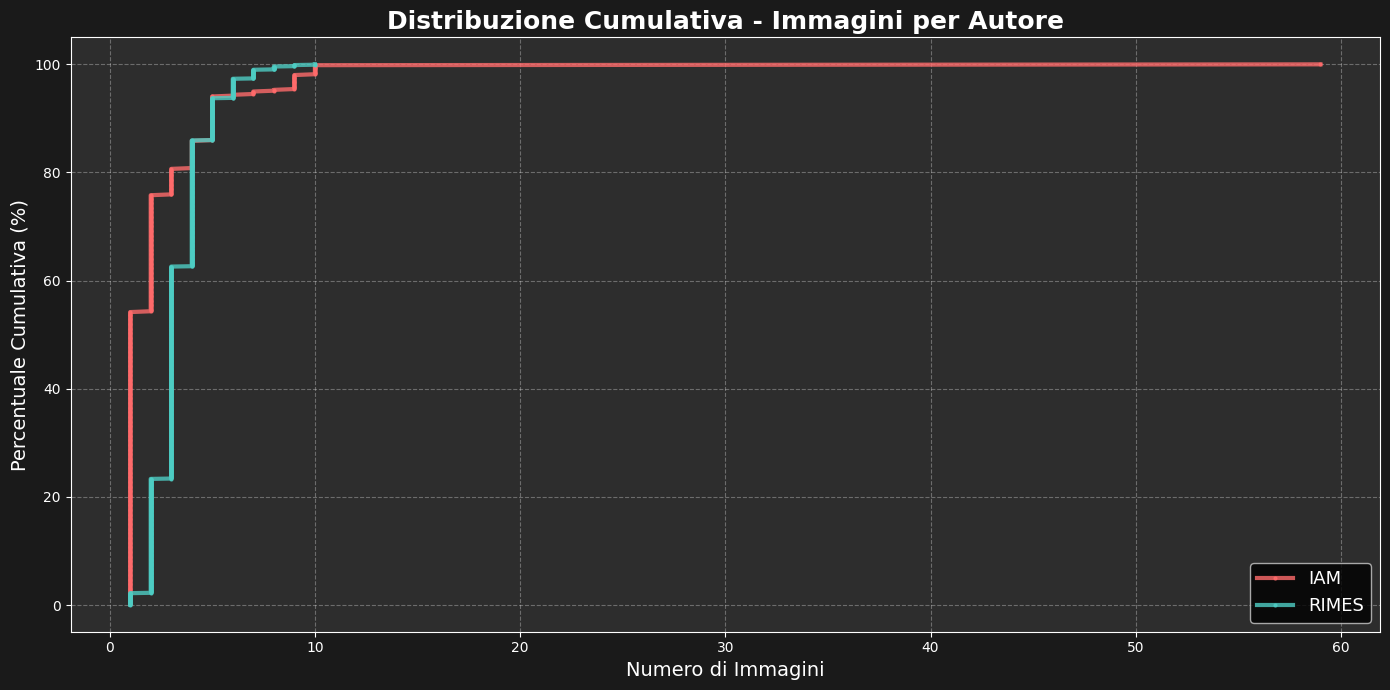

In [12]:
# ============================================================================
# CELLA 5: Distribuzione cumulativa
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1a1a1a')

for name, color in zip(['IAM', 'RIMES'], colors):
    subset = df[df['dataset'] == name]['num_images'].sort_values()
    cumulative = np.arange(1, len(subset) + 1) / len(subset) * 100
    
    ax.plot(subset.values, cumulative, linewidth=3, label=name, 
            color=color, marker='o', markersize=2, alpha=0.8)

ax.set_title('Distribuzione Cumulativa - Immagini per Autore', 
             fontsize=18, fontweight='bold', color='white')
ax.set_xlabel('Numero di Immagini', fontsize=14, color='white')
ax.set_ylabel('Percentuale Cumulativa (%)', fontsize=14, color='white')
ax.legend(fontsize=13, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#2d2d2d')

plt.tight_layout()
plt.savefig(IMG_DIR + '/cumulative_distribution.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()


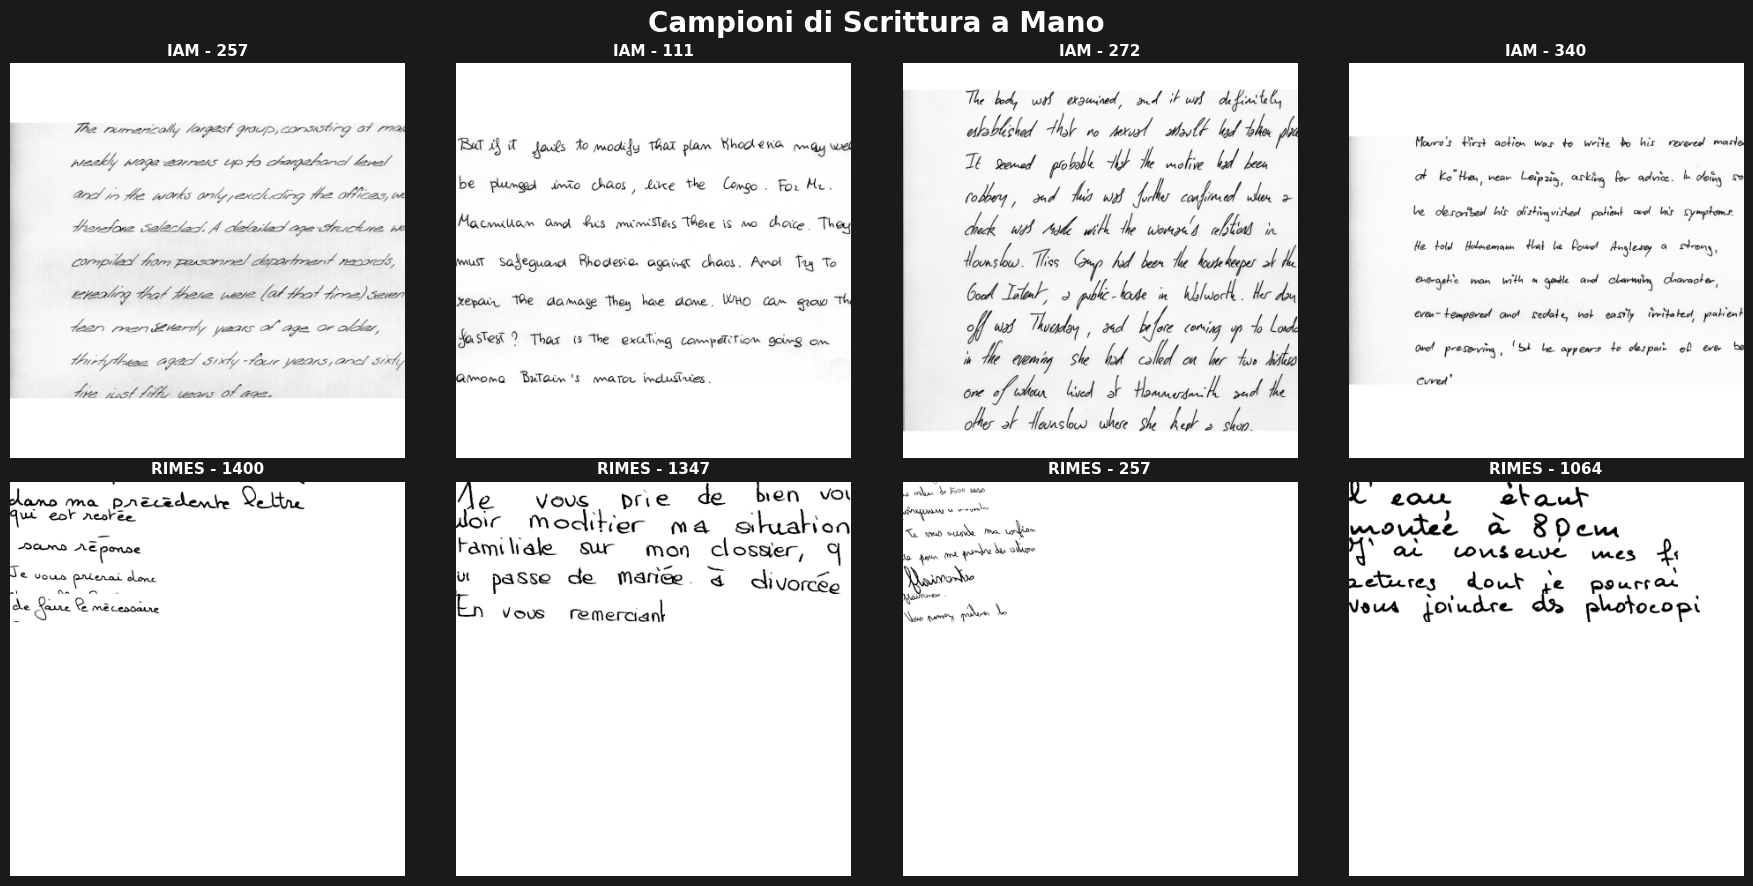


✅ Analisi completata! Grafici salvati.


In [13]:
# ============================================================================
# CELLA 6: Campioni di immagini
# ============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#1a1a1a')

for idx, (name, path) in enumerate(datasets.items()):
    authors = list(path.iterdir())[:4]
    
    for i, author_dir in enumerate(authors):
        if author_dir.is_dir():
            images = list(author_dir.glob('*.png'))
            if images:
                img = Image.open(images[0])
                axes[idx, i].imshow(img, cmap='gray')
                axes[idx, i].set_title(f"{name} - {author_dir.name}", 
                                      fontsize=11, color='white', fontweight='bold')
                axes[idx, i].axis('off')

plt.suptitle('Campioni di Scrittura a Mano', fontsize=20, 
             fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.savefig(IMG_DIR + '/sample_images.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

print("\n✅ Analisi completata! Grafici salvati.")